In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/ma3ple/pacs-dataset/data?select=kfold")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: aizelsheikh
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/ma3ple/pacs-dataset


100%|██████████| 176M/176M [00:00<00:00, 1.68GB/s]

{"username":"aizelsheikh","key":"b110d111af07944bf48bf8118001ccc4"}

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, ConcatDataset, Subset
import numpy as np
import random
from tqdm import tqdm

data_root = '/content/pacs-dataset/kfold'
domains = ['art_painting', 'cartoon', 'photo', 'sketch']
# target_domain = 'photo'        # <-- unseen target
batch_size = 32
lr = 5e-5
epochs = 20
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Leave-one-domain-out loop

target_domains_lood = [d for d in domains] # Domains to use as target in LOOD

all_results = {}

for target_domain in target_domains_lood:
    print(f"\n==== Training with '{target_domain}' as target domain ====")
    source_domains = [d for d in domains if d != target_domain]
    source_datasets = []
    for d in source_domains:
        ds = datasets.ImageFolder(root=f'{data_root}/{d}', transform=transform)
        print(f"Loaded {d}: {len(ds)} samples")
        source_datasets.append(ds)

    target_dataset = datasets.ImageFolder(root=f'{data_root}/{target_domain}', transform=transform)
    print(f"Loaded target domain {target_domain}: {len(target_dataset)} samples")

    # Merge all source domains
    train_dataset = ConcatDataset(source_datasets)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

    # For evaluation: one loader per domain
    val_loaders = {d: DataLoader(datasets.ImageFolder(root=f'{data_root}/{d}', transform=transform),
                                 batch_size=batch_size, shuffle=False, num_workers=4)
                   for d in domains}



    # Model: Standard ResNet18 (re-initialize for each LOOD split)

    model = models.resnet18(weights='IMAGENET1K_V1')
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 7)  # PACS has 7 classes
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Lists to store metrics for this split
    train_losses = []
    train_accuracies = []

    # Training loop (ERM)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct, total = 0, 0
        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        avg_loss = total_loss / len(train_loader)
        acc = correct / total * 100

        train_losses.append(avg_loss)
        train_accuracies.append(acc)

        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Train Acc: {acc:.2f}%")

    # Evaluation for this LOOD split

    def evaluate(loader):
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        return correct / total * 100

    results = {}
    for d, loader in val_loaders.items():
        acc = evaluate(loader)
        results[d] = acc
        print(f"Accuracy on {d}: {acc:.2f}%")

    source_accs = [results[d] for d in source_domains]
    target_acc = results[target_domain]
    print(f"\n==== Results for target domain '{target_domain}' ====")
    print(f"Source domains ({source_domains}) average: {np.mean(source_accs):.2f}%")
    print(f"Target domain ({target_domain}) accuracy: {target_acc:.2f}%")
    print("======================================================")

    all_results[target_domain] = {
        'source_domains': source_domains,
        'source_average_accuracy': np.mean(source_accs),
        'target_accuracy': target_acc,
        'domain_accuracies': results
    }

# Overall LOOD Results

print("\n==== Overall Leave-One-Domain-Out Results ====")
for target_domain, data in all_results.items():
    print(f"Target Domain: {target_domain}")
    print(f"  Source Domains: {data['source_domains']}")
    print(f"  Source Average Accuracy: {data['source_average_accuracy']:.2f}%")
    print(f"  Target Accuracy: {data['target_accuracy']:.2f}%")
    # print(f"  Domain Accuracies: {data['domain_accuracies']}") # Optional: uncomment to see individual domain results
    print("-" * 30)

average_target_accuracy = np.mean([data['target_accuracy'] for data in all_results.values()])
print(f"\nAverage Target Accuracy across LOOD splits: {average_target_accuracy:.2f}%")
print("============================================================")

Device: cuda

==== Training with 'art_painting' as target domain ====
Loaded cartoon: 2344 samples
Loaded photo: 1670 samples
Loaded sketch: 3929 samples
Loaded target domain art_painting: 2048 samples


Epoch 1/20: 100%|██████████| 249/249 [00:06<00:00, 36.13it/s]


Epoch [1/20] | Loss: 0.4652 | Train Acc: 85.45%


Epoch 2/20: 100%|██████████| 249/249 [00:06<00:00, 36.77it/s]


Epoch [2/20] | Loss: 0.1097 | Train Acc: 97.08%


...

Epoch 19/20: 100%|██████████| 190/190 [00:05<00:00, 36.36it/s]


Epoch [19/20] | Loss: 0.0014 | Train Acc: 100.00%


Epoch 20/20: 100%|██████████| 190/190 [00:05<00:00, 36.22it/s]

Epoch [20/20] | Loss: 0.0099 | Train Acc: 99.65%


Accuracy on art_painting: 99.90%
Accuracy on cartoon: 99.62%
Accuracy on photo: 99.94%
Accuracy on sketch: 50.62%

==== Results for target domain 'sketch' ====
Source domains (['art_painting', 'cartoon', 'photo']) average: 99.82%
Target domain (sketch) accuracy: 50.62%

==== Overall Leave-One-Domain-Out Results (excluding 'photo') ====
Target Domain: art_painting
  Source Domains: ['cartoon', 'photo', 'sketch']
  Source Average Accuracy: 100.00%
  Target Accuracy: 82.47%
------------------------------
Target Domain: cartoon
  Source Domains: ['art_painting', 'photo', 'sketch']
  Source Average Accuracy: 99.89%
  Target Accuracy: 74.45%
------------------------------
Target Domain: photo
  Source Domains: ['art_painting', 'cartoon', 'sketch']
  Source Average Accuracy: 99.92%
  Target Accuracy: 94.13%
------------------------------
Target Domain: sketch
  Source Domains: ['art_painting', 'cartoon', 'photo']
  Source Average Accuracy: 99.82%
  Target Accuracy: 50.62%
--------------------

ERM model checkpoint saved to ./erm_resnet18_pacs.pth


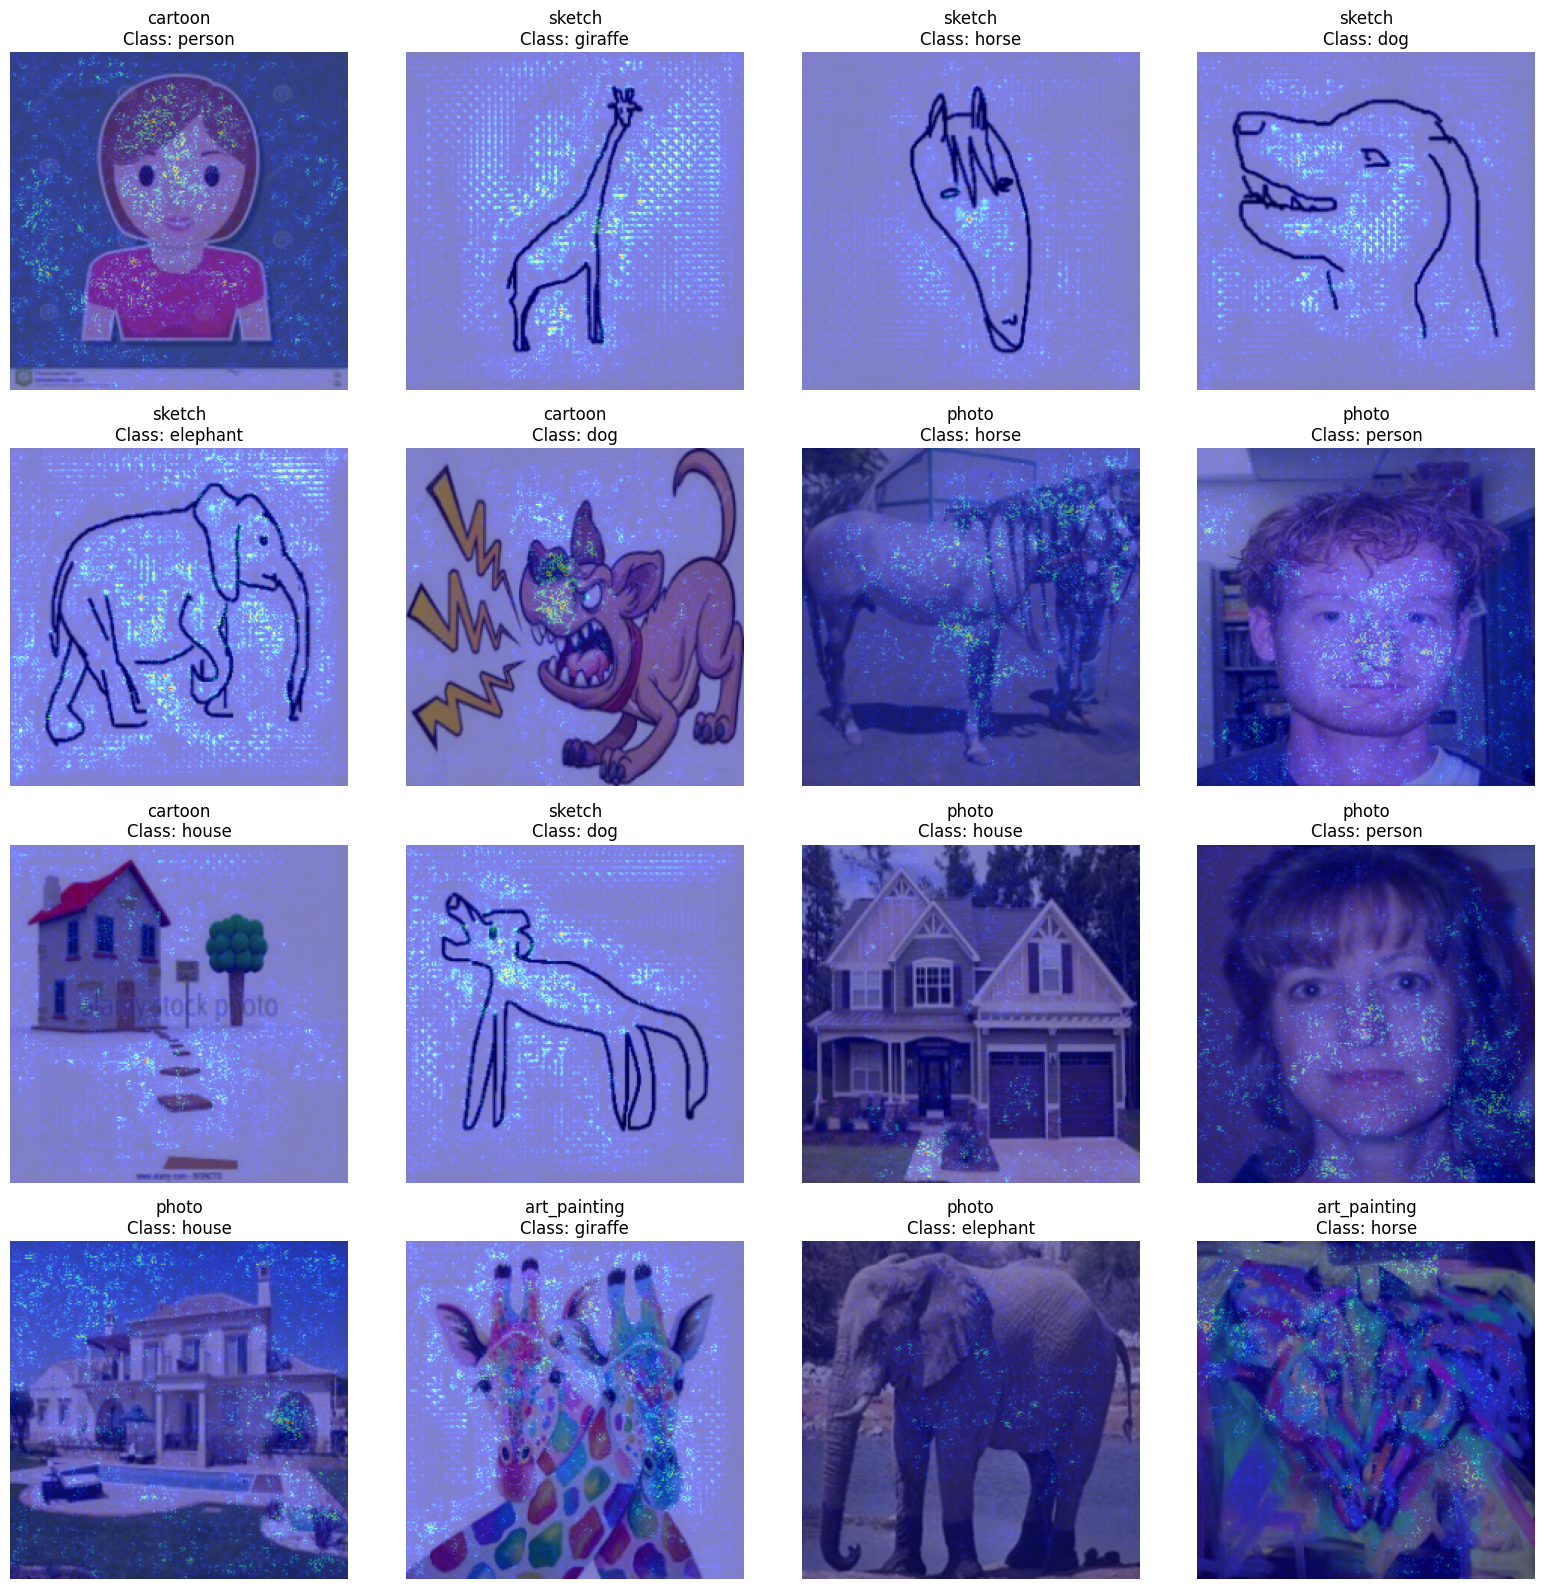

In [11]:
# Saliency Map Generation and Visualization

def generate_saliency_map(img_tensor, model):
    """
    Computes vanilla gradient saliency map for a single image.
    """
    model.zero_grad()
    img_tensor = img_tensor.unsqueeze(0).to(device)
    img_tensor.requires_grad_(True)
    output = model(img_tensor)
    target_class = output.argmax(dim=1)
    loss = output[0, target_class]
    loss.backward()

    saliency = img_tensor.grad.abs().max(dim=1)[0]
    saliency = (saliency - saliency.min()) / (saliency.max() + 1e-8)
    return saliency.squeeze(0).cpu()

def show_saliency_map_overlay(img_tensor, saliency_map):
    """
    Overlays normalized saliency heatmap on original image.
    """
    # De-normalize for visualization
    img_vis = inv_normalize(img_tensor.cpu()).permute(1, 2, 0).numpy()
    img_vis = np.clip(img_vis, 0, 1)

    saliency_resized = cv2.resize(saliency_map.numpy(), (img_vis.shape[1], img_vis.shape[0]))
    cmap = plt.get_cmap('jet')
    heatmap = cmap(saliency_resized)[:, :, :3]
    overlay = 0.5 * img_vis + 0.5 * heatmap
    return np.clip(overlay, 0, 1)

# Visualize 16 Random Samples

num_images_to_show = 16
sample_indices = random.sample(range(len(combined_dataset)), num_images_to_show)
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

# Precompute domain lengths for fast lookup
domain_lengths = [len(ds) for ds in all_datasets]
domain_boundaries = np.cumsum([0] + domain_lengths)

for i, idx in enumerate(sample_indices):
    img, label = combined_dataset[idx]
    saliency_map = generate_saliency_map(img, model)
    overlay_img = show_saliency_map_overlay(img, saliency_map)

    # Find domain
    domain_name = None
    for d_idx, boundary in enumerate(domain_boundaries[:-1]):
        if boundary <= idx < domain_boundaries[d_idx + 1]:
            domain_name = domains[d_idx]
            break

    axes[i].imshow(overlay_img)
    class_name = all_datasets[0].classes[label]
    axes[i].set_title(f"{domain_name}\nClass: {class_name}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


Extracting features: 100%|██████████| 123/123 [00:05<00:00, 21.21it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Running t-SNE ... (this may take a few minutes)
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 9991 samples in 0.003s...
[t-SNE] Computed neighbors for 9991 samples in 0.687s...
[t-SNE] Computed conditional probabilities for sample 1000 / 9991
[t-SNE] Computed conditional probabilities for sample 2000 / 9991
[t-SNE] Computed conditional probabilities for sample 3000 / 9991
[t-SNE] Computed conditional probabilities for sample 4000 / 9991
[t-SNE] Computed conditional probabilities for sample 5000 / 9991
[t-SNE] Computed conditional probabilities for sample 6000 / 9991
[t-SNE] Computed conditional probabilities for sample 7000 / 9991
[t-SNE] Computed conditional probabilities for sample 8000 / 9991
[t-SNE] Computed conditional probabilities for sample 9000 / 9991
[t-SNE] Computed conditional probabilities for sample 9991 / 9991
[t-SNE] Mean sigma: 2.915005
[t-SNE] KL divergence after 250 iterations with early exaggeration: 74.844742
[t-SNE] KL divergence after 1500 iterations:

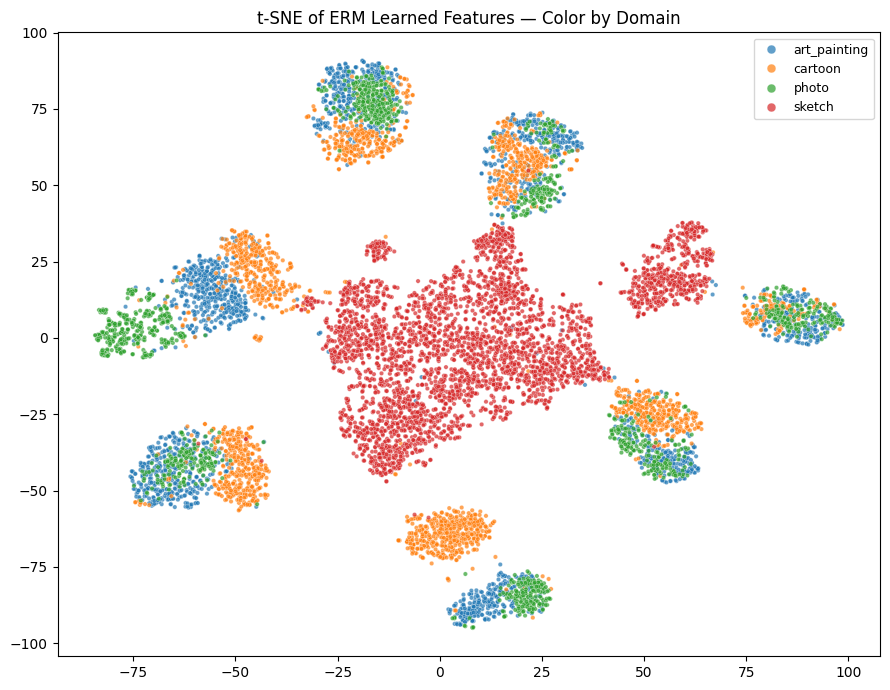

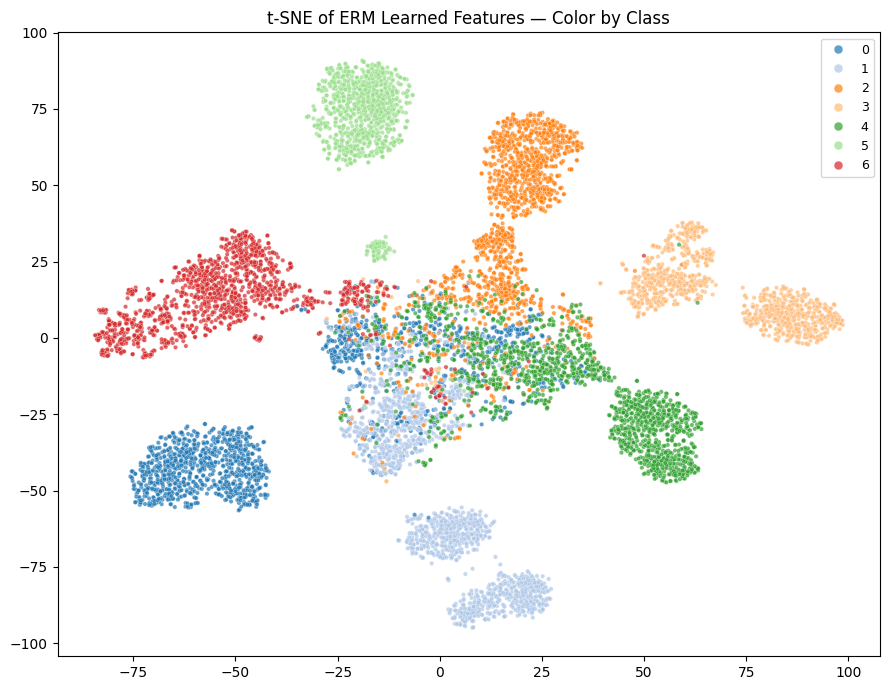

In [13]:
# t-SNE Visualization of ERM Features

from sklearn.manifold import TSNE
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

def extract_features(model, loader):
    """
    Extract penultimate-layer features (before final FC) for visualization.
    """
    model.eval()
    feats_list, labels_list = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Extracting features"):
            imgs = imgs.to(device)
            # Forward until avgpool layer
            x = model.conv1(imgs)
            x = model.bn1(x)
            x = model.relu(x)
            x = model.maxpool(x)
            x = model.layer1(x)
            x = model.layer2(x)
            x = model.layer3(x)
            x = model.layer4(x)
            x = model.avgpool(x)
            x = torch.flatten(x, 1)
            feats_list.append(x.cpu().numpy())
            labels_list.append(lbls.numpy())
    features = np.concatenate(feats_list)
    labels = np.concatenate(labels_list)
    return features, labels

# Gather features across all domains

domain_features, domain_labels, domain_tags = [], [], []

for domain in domains:
    ds = ImageFolder(root=f'{data_root}/{domain}', transform=transform)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)
    feats, lbls = extract_features(model, loader)
    domain_features.append(feats)
    domain_labels.append(lbls)
    domain_tags += [domain] * len(lbls)

features = np.concatenate(domain_features)
labels = np.concatenate(domain_labels)

print("Running t-SNE ... (this may take a few minutes)")
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1500,
            init='pca', random_state=42, verbose=1)
X_embedded = tsne.fit_transform(features)

# Plot by DOMAIN

plt.figure(figsize=(9,7))
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1],
                hue=domain_tags, palette='tab10', s=10, alpha=0.7)
plt.title("t-SNE of ERM Learned Features — Color by Domain")
plt.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()

# Plot by CLASS

plt.figure(figsize=(9,7))
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1],
                hue=labels, palette='tab20', s=10, alpha=0.7)
plt.title("t-SNE of ERM Learned Features — Color by Class")
plt.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()

  Target Domain  Source Avg Accuracy (%)  Target Accuracy (%)  \
0  art_painting                   100.00                82.47   
1       cartoon                    99.89                74.45   
2         photo                    99.92                94.13   
3        sketch                    99.82                50.62   

   Generalization Gap (%)  
0                   17.53  
1                   25.44  
2                    5.79  
3                   49.20  


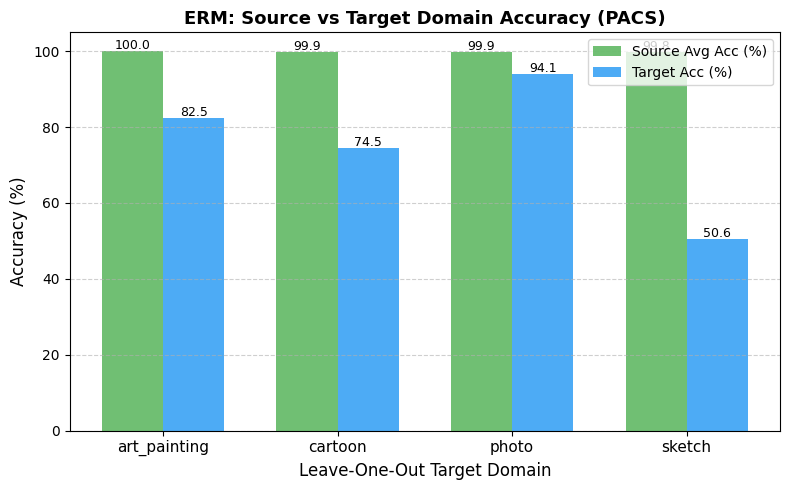

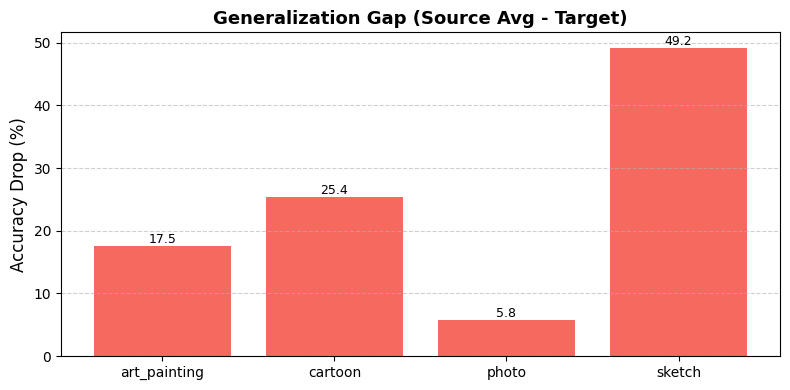

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

targets = ['art_painting', 'cartoon', 'photo', 'sketch']
source_accs = [100.00, 99.89, 99.92, 99.82]
target_accs = [82.47, 74.45, 94.13, 50.62]
gaps = np.array(source_accs) - np.array(target_accs)

results_df = pd.DataFrame({
    'Target Domain': targets,
    'Source Avg Accuracy (%)': source_accs,
    'Target Accuracy (%)': target_accs,
    'Generalization Gap (%)': gaps
})

print(results_df.round(2))

# Plot: Source vs Target Accuracy

x = np.arange(len(targets))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, source_accs, width, label='Source Avg Acc (%)', color='#4CAF50', alpha=0.8)
plt.bar(x + width/2, target_accs, width, label='Target Acc (%)', color='#2196F3', alpha=0.8)

for i, v in enumerate(source_accs):
    plt.text(i - width/2, v + 0.5, f"{v:.1f}", ha='center', fontsize=9)
for i, v in enumerate(target_accs):
    plt.text(i + width/2, v + 0.5, f"{v:.1f}", ha='center', fontsize=9)

plt.xticks(x, targets, fontsize=11)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xlabel('Leave-One-Out Target Domain', fontsize=12)
plt.title('ERM: Source vs Target Domain Accuracy (PACS)', fontsize=13, weight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plot: Domain Generalization Gap

plt.figure(figsize=(8, 4))
plt.bar(targets, gaps, color='#F44336', alpha=0.8)

for i, v in enumerate(gaps):
    plt.text(i, v + 0.5, f"{v:.1f}", ha='center', fontsize=9)

plt.title('Generalization Gap (Source Avg - Target)', fontsize=13, weight='bold')
plt.ylabel('Accuracy Drop (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
